# qvarnet — Master Example

Comprehensive walkthrough of every feature in the library.
Run cells in order; each section is self-contained after the **Setup** block.

> **Kernel**: make sure you are using the `qvarnet` uv environment.
> From the repo root: `uv run jupyter lab examples/MASTER_EXAMPLE.ipynb`

**Sections**
1. [Setup](#1-setup)
2. [Quickstart — 1D harmonic oscillator](#2-quickstart)
3. [Models gallery](#3-models)
4. [Hamiltonians gallery](#4-hamiltonians)
5. [TrainingConfig / SamplingConfig reference](#5-config)
6. [Coordinate modes](#6-coords)
7. [Analysing results (TrainResult)](#7-results)
8. [MCMC diagnostics — autocorrelation & ESS](#8-diagnostics)
9. [Block sampling](#9-block)
10. [Laplacian methods](#10-laplacian)
11. [Stochastic reconfiguration (QGT)](#11-qgt)
12. [Callbacks](#12-callbacks)
13. [Checkpointing](#13-checkpoints)
14. [Custom Hamiltonian](#14-custom-hamiltonian)
15. [Custom model](#15-custom-model)
16. [Auxiliary losses — cusp condition](#16-cusp)
17. [YAML config runner](#17-yaml)


---

## 1. Setup <a name='1-setup'></a>

In [17]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

# qvarnet core
from qvarnet import train, TrainResult
from qvarnet.config.training_setup import TrainingConfig, SamplingConfig
from qvarnet.config.coord_mode import LabCoords, JacobiCoords
from qvarnet.probability import build_prob_fn

# Models
from qvarnet.models import (
    MLP, ExponentialMLPwithPenalty, ExponentialDeepSet,
    FermionicMLP, MODEL_REGISTRY,
)
from qvarnet.models.layers import SubtractCM, AppendPairwiseDiffs

# Hamiltonians
from qvarnet.hamiltonian.continuous import (
    HarmonicOscillatorHamiltonian,
    NN_OscillatorHamiltonian,
    CalogeroSutherlandHamiltonian,
    SoftCoreHamiltonian,
)
from qvarnet.hamiltonian import define_hamiltonian, list_hamiltonians, get_hamiltonian

# Samplers & diagnostics
from qvarnet.samplers import (
    mh_chain,
    autocorr, integrated_autocorr_time, effective_sample_size, chain_stats,
)

# Callbacks
from qvarnet.callbacks import Callback, CheckpointCallback

print('JAX devices:', jax.devices())
print('JAX version:', jax.__version__)


JAX devices: [CudaDevice(id=0)]
JAX version: 0.7.0


---

## 2. Quickstart — 1D harmonic oscillator <a name='2-quickstart'></a>

Exact ground-state energy of the 1D QHO with ω=1 is **E₀ = ½ ħω = 0.5**.
The model outputs log|ψ(x)|.


In [18]:
model_ho = MLP(architecture=[1, 32, 32, 1])

result_ho = train(
    shape=(500, 1),                       # 500 chains, dof=1
    model=model_ho,
    optimizer=optax.adam(3e-3),
    hamiltonian=HarmonicOscillatorHamiltonian(omega=1.0),
    training_config=TrainingConfig(
        n_epochs=300,
        is_update_step_size=True,
    ),
    sampler_params={
        'step_size': 0.5,
        'chain_length': 100,
        'thermalization_steps': 10,
        'thinning_factor': 2,
    },
)

energies = [float(s.energy) for s in result_ho.history]
print(f'Final energy : {energies[-1]:.4f}  (exact = 0.5000)')
print(f'Best 10-epoch mean: {np.mean([float(s.energy) for s in result_ho.best(10)]):.4f}')


100%|██████████| 300/300 [00:03<00:00, 81.89it/s, E=1.2181, sigma_E=1.7383]  


Final energy : 1.1043  (exact = 0.5000)
Best 10-epoch mean: 1.1184


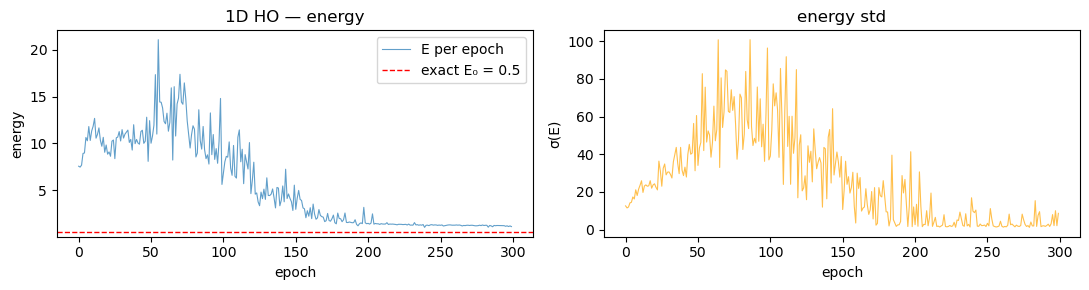

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

axes[0].plot(energies, lw=0.8, alpha=0.7, label='E per epoch')
axes[0].axhline(0.5, color='r', ls='--', lw=1, label='exact E₀ = 0.5')
axes[0].set(xlabel='epoch', ylabel='energy', title='1D HO — energy')
axes[0].legend()

stds = [float(s.std) for s in result_ho.history]
axes[1].plot(stds, lw=0.8, alpha=0.7, color='orange')
axes[1].set(xlabel='epoch', ylabel='σ(E)', title='energy std')

plt.tight_layout()
plt.show()


---

## 3. Models gallery <a name='3-models'></a>

All models output **log|ψ(x)|** (use `is_log_model=True` convention).
The last entry of `architecture` must always be `1`.


### 3.1 MLP
Standard fully-connected network. `architecture = [in, h1, h2, ..., 1]`.

In [20]:
# 3-particle system, 1D → dof = 3
dof = 3
mlp = MLP(architecture=[dof, 64, 64, 1])

key = jax.random.PRNGKey(0)
x = jnp.ones((4, dof))
params_mlp = mlp.init(key, x)
out = mlp.apply(params_mlp, x)
print('MLP output shape:', out.shape)   # (4, 1)
n_params = sum(p.size for p in jax.tree_util.tree_leaves(params_mlp))
print(f'Parameters: {n_params}')


MLP output shape: (4, 1)
Parameters: 4481


### 3.2 ExponentialMLPwithPenalty
MLP with a built-in Gaussian or quartic envelope to enforce ψ → 0 at infinity.

In [21]:
# ExponentialMLPwithPenalty: MLP + learnable quartic envelope
# log|ψ| = MLP(x) - λ·Σ xᵢ⁴   where λ is a trainable parameter
exp_mlp = ExponentialMLPwithPenalty(architecture=[3, 32, 32, 1])
params_exp = exp_mlp.init(key, x)
print("ExponentialMLP output shape:", exp_mlp.apply(params_exp, x).shape)

# LogExponentialMLPwithGaussianPenalty: Gaussian envelope variant
from qvarnet.models.exponential import LogExponentialMLPwithGaussianPenalty
exp_gauss = LogExponentialMLPwithGaussianPenalty(architecture=[3, 32, 32, 1])
params_eg = exp_gauss.init(key, x)
print("GaussianPenalty output shape:", exp_gauss.apply(params_eg, x).shape)


ExponentialMLP output shape: (4, 1)
GaussianPenalty output shape: (4, 1)


### 3.3 ExponentialDeepSet
Permutation-invariant architecture: per-particle embedding φ → symmetric aggregation → F.
Use for bosonic systems where ψ(x₁, …, xₙ) = ψ(xₚ₁, …, xₚₙ).


In [22]:
n_particles, n_dim = 4, 1
deep_set = ExponentialDeepSet(
    n_particles=n_particles,
    n_dim=n_dim,
    phi_hidden_architecture=[16, 16],    # per-particle network widths
    F_hidden_architecture=[32, 1],       # aggregation network widths
)
x_ds = jnp.ones((8, n_particles * n_dim))
params_ds = deep_set.init(key, x_ds)
print('DeepSet output shape:', deep_set.apply(params_ds, x_ds).shape)

# Verify permutation invariance
x0 = jax.random.normal(key, (1, n_particles * n_dim))
x0_perm = x0.reshape(1, n_particles, n_dim)[:, [1, 0, 2, 3], :].reshape(1, -1)
v1 = deep_set.apply(params_ds, x0)
v2 = deep_set.apply(params_ds, x0_perm)
print(f'Permutation invariant: |Δ| = {abs(float(v1.squeeze()) - float(v2.squeeze())):.2e}  (should be ~0)')


DeepSet output shape: (8, 1)
Permutation invariant: |Δ| = 0.00e+00  (should be ~0)


### 3.4 FermionicMLP
Antisymmetric wavefunction via Slater-determinant structure.

In [23]:
n_f, d = 3, 1
# FermionicMLP takes architecture (same convention as MLP) + n_fermions
fermi = FermionicMLP(
    architecture=[n_f * d, 32, 32, 1],
    n_fermions=n_f,
    n_dim=d,
)
xf = jnp.ones((4, n_f * d))
params_f = fermi.init(key, xf)
print("FermionicMLP output shape:", fermi.apply(params_f, xf).shape)

# Verify antisymmetry (swap particles 0 and 1 — sign of ψ flips, log|ψ| is unchanged)
x1 = jax.random.normal(key, (1, n_f * d))
x1_swap = x1.reshape(1, n_f, d)[:, [1, 0, 2], :].reshape(1, -1)
v_orig = fermi.apply(params_f, x1)
v_swap = fermi.apply(params_f, x1_swap)
print(f"log|ψ| orig={float(v_orig.squeeze()):.4f}, swap={float(v_swap.squeeze()):.4f}  "
      f"(equal because antisymmetry lives in ψ, not log|ψ|)")


FermionicMLP output shape: (4,)
log|ψ| orig=0.0000, swap=0.0000  (equal because antisymmetry lives in ψ, not log|ψ|)


### 3.5 Input transforms: SubtractCM and AppendPairwiseDiffs
These are drop-in **first layers** that augment or reshape coordinates before the main network.


In [24]:
from flax import linen as nn

class ModelWithCM(nn.Module):
    """MLP that first removes the centre-of-mass."""
    n_particles: int
    n_dim: int

    @nn.compact
    def __call__(self, x):
        x = SubtractCM(n_particles=self.n_particles, n_dim=self.n_dim)(x)
        x = nn.Dense(32)(x); x = nn.tanh(x)
        x = nn.Dense(32)(x); x = nn.tanh(x)
        return nn.Dense(1)(x)


class ModelWithPairs(nn.Module):
    """MLP augmented with all pairwise differences."""
    n_particles: int
    n_dim: int

    @nn.compact
    def __call__(self, x):
        x = AppendPairwiseDiffs(n_particles=self.n_particles, n_dim=self.n_dim)(x)
        x = nn.Dense(32)(x); x = nn.tanh(x)
        x = nn.Dense(32)(x); x = nn.tanh(x)
        return nn.Dense(1)(x)


N, d = 4, 1
x_test = jnp.ones((2, N * d))

m_cm = ModelWithCM(N, d)
m_pw = ModelWithPairs(N, d)

n_pairs = N * (N - 1) // 2
print(f'Input dof = {N*d}')
print(f'AppendPairwiseDiffs → augmented dof = {N*d + n_pairs*d}')
p_cm = m_cm.init(key, x_test)
p_pw = m_pw.init(key, x_test)
print('SubtractCM model output:', m_cm.apply(p_cm, x_test).shape)
print('AppendPairwiseDiffs model output:', m_pw.apply(p_pw, x_test).shape)


Input dof = 4
AppendPairwiseDiffs → augmented dof = 10
SubtractCM model output: (2, 1)
AppendPairwiseDiffs model output: (2, 1)


### 3.6 MODEL_REGISTRY — all registered models

In [25]:
print('Registered models:')
for name in sorted(MODEL_REGISTRY):
    print(f'  {name!r}')


Registered models:
  'deep-set'
  'exponential-deep-set'
  'exponential-mlp-fourth-decay'
  'fermionic-mlp'
  'fermionic-mlp-2'
  'half-spin-non-interacting-fermion'
  'j-mlp-gaussian-decay'
  'log-analytic'
  'mlp'
  'mlp-fourth-decay'
  'mlp-gaussian-decay'
  'pair-exponential-mlp-gaussian-decay'


---

## 4. Hamiltonians gallery <a name='4-hamiltonians'></a>

All Hamiltonians are Flax `struct.dataclass` (JAX-pytree compatible).
`potential_energy(samples)` always receives **lab coordinates** regardless of coord_mode.


### 4.1 HarmonicOscillatorHamiltonian
V(x) = ½ω² Σ xᵢ²

In [26]:
ho_1d = HarmonicOscillatorHamiltonian(omega=1.0)
ho_3d = HarmonicOscillatorHamiltonian(omega=2.0)

result_3d = train(
    shape=(200, 3),
    model=MLP(architecture=[3, 32, 32, 1]),
    optimizer=optax.adam(3e-3),
    hamiltonian=ho_3d,
    training_config=TrainingConfig(n_epochs=100, is_update_step_size=True),
    sampler_params={'step_size': 0.3, 'chain_length': 80, 'thermalization_steps': 8, 'thinning_factor': 2},
)
# Exact E₀(3D, ω=2) = 3 * ½*2 = 3.0
print(f'3D HO (ω=2) final E = {result_3d.history[-1].energy:.4f}  (exact = 3.0000)')


100%|██████████| 100/100 [00:04<00:00, 20.17it/s, E=8.4589, sigma_E=9.0064]   


3D HO (ω=2) final E = 7.3794  (exact = 3.0000)


### 4.2 NN_OscillatorHamiltonian
Trap + nearest-neighbour harmonic interactions. Can use periodic boundary conditions.

In [27]:
nn_osc = NN_OscillatorHamiltonian(
    omega_trap=1.0,
    omega_interaction=0.5,
    with_pbc=False,           # open chain
)
N = 4
result_nn = train(
    shape=(200, N),
    model=MLP(architecture=[N, 32, 32, 1]),
    optimizer=optax.adam(3e-3),
    hamiltonian=nn_osc,
    training_config=TrainingConfig(n_epochs=80),
    sampler_params={'step_size': 0.3, 'chain_length': 60, 'thermalization_steps': 6, 'thinning_factor': 1},
)
print(f'NN oscillator N={N} final E = {result_nn.history[-1].energy:.4f}')


100%|██████████| 80/80 [00:02<00:00, 30.04it/s, E=4.2793, sigma_E=4.5026]

NN oscillator N=4 final E = 3.4104


### 4.3 CalogeroSutherlandHamiltonian
H = −2 d²/dx² + ω²x² + Σᵢ<ⱼ L(L−1)/(xᵢ−xⱼ)²

Note: kinetic energy uses a factor-of-2 convention (ℏ²/m = 1, not ℏ²/2m = 1).
Two pairwise implementations: `vectorized` (GPU-friendly) and `scan` (memory-efficient).


In [28]:
cs = CalogeroSutherlandHamiltonian(
    L=2.0,                   # coupling: L=0 → free gas, L=integer → exactly solvable
    epsilon=1e-3,            # regularisation for near-coincident particles
    omega_trap=1.0,
    pairwise_impl='vectorized',   # or 'scan' for large N
)
N = 3
result_cs = train(
    shape=(200, N),
    model=MLP(architecture=[N, 64, 64, 1]),
    optimizer=optax.adam(1e-3),
    hamiltonian=cs,
    training_config=TrainingConfig(n_epochs=100, is_update_step_size=True),
    sampler_params={'step_size': 0.2, 'chain_length': 100, 'thermalization_steps': 10, 'thinning_factor': 2},
)
# Exact E₀(N=3, L=2, ω=1) = 2*(N^2 * L^2/4 ... complex formula, see CS literature)
print(f'CS model N={N} L=2 final E = {result_cs.history[-1].energy:.4f}')


100%|██████████| 100/100 [00:06<00:00, 15.80it/s, E=273.6371, sigma_E=354.9700]

CS model N=3 L=2 final E = 239.6538


In [29]:
# Memory-efficient scan variant (same physics, O(B·N) peak random memory)
cs_scan = CalogeroSutherlandHamiltonian(
    L=2.0, epsilon=1e-3, omega_trap=1.0,
    pairwise_impl='scan',
)
samples = jax.random.normal(jax.random.PRNGKey(1), (16, N))
v_vec  = CalogeroSutherlandHamiltonian(L=2.0, epsilon=1e-3, omega_trap=1.0, pairwise_impl='vectorized').potential_energy(samples)
v_scan = cs_scan.potential_energy(samples)
print(f'Max |V_vec - V_scan| = {float(jnp.max(jnp.abs(v_vec - v_scan))):.2e}  (should be ~0)')


Max |V_vec - V_scan| = 0.00e+00  (should be ~0)


### 4.4 SoftCoreHamiltonian
Hard-sphere-like potential: V = V₀ if r < R, else 0.

In [30]:
sc_ham = SoftCoreHamiltonian(R=1.0, V0=5.0)
samples_sc = jax.random.normal(jax.random.PRNGKey(0), (8, 3))
print('SoftCore V:', sc_ham.potential_energy(samples_sc))


SoftCore V: [0. 5. 5. 0. 0. 0. 0. 0.]


### 4.5 define_hamiltonian — runtime construction from name

In [31]:
print('Registered Hamiltonians:', list_hamiltonians())

# get_hamiltonian: construct by name with kwargs
from qvarnet.hamiltonian import get_hamiltonian
h = get_hamiltonian('harmonic-oscillator', omega=2.0)
print('Constructed:', h)

# define_hamiltonian: decorator that creates a new Hamiltonian class from a plain function
@define_hamiltonian('custom-ho-demo')
def custom_potential(samples, omega=1.0):
    return 0.5 * omega**2 * jnp.sum(samples**2, axis=-1)

h2 = get_hamiltonian('custom-ho-demo', omega=3.0)
print('Defined via decorator:', h2)


Registered Hamiltonians: ['harmonic-oscillator', 'nn-oscillator', 'soft-core', 'gross-struct-hamiltonian', 'CS-model']
Constructed: HarmonicOscillatorHamiltonian(laplacian_method='forward_ad', coord_mode=None, hutchinson_n_terms=10, hutchinson_distribution='rademacher', omega=2.0)
Defined via decorator: custom-ho-demo_Hamiltonian(laplacian_method='forward_ad', coord_mode=None, hutchinson_n_terms=10, hutchinson_distribution='rademacher', omega=3.0)


---

## 5. TrainingConfig / SamplingConfig reference <a name='5-config'></a>

### 5.1 TrainingConfig — all fields

In [32]:
cfg = TrainingConfig(
    n_epochs=500,
    rng_seed=42,
    init_positions='normal',       # 'normal' | 'zeros'
    warm_walkers=True,             # persist chain positions between epochs
    is_update_step_size=True,      # adapt step size toward target_acceptance
    target_acceptance=0.5,
    adaptation_rate=0.1,
    min_step=1e-4,
    max_step=3.0,
    use_qgt=False,                 # stochastic reconfiguration (see §11)
    save_checkpoints=False,        # save every 50 epochs
    checkpoint_path='./checkpoints',
    cusp=None,                     # CuspConfig or None (see §16)
)
print(cfg)


TrainingConfig(n_epochs=500, rng_seed=42, init_positions='normal', warm_walkers=True, is_update_step_size=True, min_step=0.0001, max_step=3.0, use_qgt=False, checkpoint_path='./checkpoints', save_checkpoints=False, target_acceptance=0.5, adaptation_rate=0.1, cusp=None)


### 5.2 SamplingConfig — dict form vs object form

In [33]:
# ── Dict form (any unset key uses default) ──────────────────────────────
sampler_dict = {
    'step_size': 0.4,
    'chain_length': 200,
    'thermalization_steps': 20,
    'thinning_factor': 2,
    'PBC': 0.0,
    'block_size': 0,       # 0 = no blocking (see §9)
}

# ── SamplingConfig object ────────────────────────────────────────────────
sampler_cfg = SamplingConfig(
    step_size=0.4,
    chain_length=200,
    thermalization_steps=20,
    thinning_factor=2,
    PBC=0.0,
    block_size=0,
)
print(sampler_cfg)

# Validation examples
try:
    SamplingConfig(step_size=-0.1, chain_length=100, thermalization_steps=10,
                   thinning_factor=1, PBC=0.0)
except ValueError as e:
    print(f'Caught: {e}')

try:
    SamplingConfig(step_size=0.3, chain_length=100, thermalization_steps=10,
                   thinning_factor=1, PBC=0.0, block_size=30)   # 30 doesn't divide 100
except ValueError as e:
    print(f'Caught: {e}')


SamplingConfig(step_size=0.4, chain_length=200, thermalization_steps=20, thinning_factor=2, PBC=0.0, block_size=0)
Caught: step_size must be positive, got -0.1
Caught: block_size (30) must divide chain_length (100) exactly.


---

## 6. Coordinate modes <a name='6-coords'></a>

Coordinate modes control the relationship between the **sampler** coordinates
and the **model** coordinates.

| Mode | Sampler | Model receives | Use case |
|---|---|---|---|
| `LabCoords` | lab x | lab x | default; simplest |
| `JacobiCoords` | Jacobi ξ | lab x (auto-converted) | N-body, removes CM |


In [34]:
# LabCoords: default, no transformation
result_lab = train(
    shape=(200, 4),
    model=MLP(architecture=[4, 32, 1]),
    optimizer=optax.adam(3e-3),
    hamiltonian=HarmonicOscillatorHamiltonian(),
    training_config=TrainingConfig(n_epochs=40),
    sampler_params={'step_size': 0.4, 'chain_length': 60, 'thermalization_steps': 6, 'thinning_factor': 1},
    coord_mode=LabCoords(),
)
print(f'LabCoords  E = {result_lab.history[-1].energy:.4f}')


100%|██████████| 40/40 [00:01<00:00, 30.78it/s, E=9.3880, sigma_E=8.6887]

LabCoords  E = 9.6942


In [35]:
# JacobiCoords: n_particles_physical = total particles (including CM)
# sampler shape = (n_chains, (N_phys - 1) * n_dim)  — Jacobi relative coords
# model receives N_phys * n_dim lab coordinates
N_phys, d_jac = 4, 1   # 4 physical particles → 3 Jacobi DOF, 4 lab DOF
result_jac = train(
    shape=(200, (N_phys - 1) * d_jac),            # (200, 3) Jacobi DOF
    model=MLP(architecture=[N_phys * d_jac, 32, 1]),  # input = 4 lab coords
    optimizer=optax.adam(3e-3),
    hamiltonian=HarmonicOscillatorHamiltonian(),
    training_config=TrainingConfig(n_epochs=40),
    sampler_params={'step_size': 0.4, 'chain_length': 60, 'thermalization_steps': 6, 'thinning_factor': 1},
    coord_mode=JacobiCoords(n_particles_physical=N_phys, n_dim=d_jac),
)
print(f'JacobiCoords E = {result_jac.history[-1].energy:.4f}')


100%|██████████| 40/40 [00:01<00:00, 20.94it/s, E=6.8690, sigma_E=7.0978]

JacobiCoords E = 6.6115


---

## 7. Analysing results (TrainResult) <a name='7-results'></a>

`train()` returns a `TrainResult` with:
- `result.history` — list of `VMCState` (one per epoch)
- `result.best(n, metric)` — top-n epochs by metric
- `result.cm_mean`, `result.cm_std` — per-epoch centre-of-mass diagnostics


In [36]:
# Using the 1D HO result from §2
r = result_ho

# ── Accessing epoch-level quantities ─────────────────────────────────────
print('Fields on VMCState:', [f for f in dir(r.history[0]) if not f.startswith('_')])

energies_arr = np.array([float(s.energy) for s in r.history])
stds_arr     = np.array([float(s.std)    for s in r.history])
acc_arr      = np.array([float(np.mean(s.acceptance_rate)) for s in r.history])
step_arr     = np.array([float(s.step_size) for s in r.history])

print(f'Epochs: {len(r.history)}')
print(f'Mean energy (last 50): {energies_arr[-50:].mean():.5f} ± {energies_arr[-50:].std():.5f}')


Fields on VMCState: ['acceptance_rate', 'apply_fn', 'apply_gradients', 'cm_mean', 'cm_std', 'create', 'energy', 'grads', 'opt_state', 'params', 'replace', 'std', 'step', 'step_size', 'tx']
Epochs: 300
Mean energy (last 50): 1.21427 ± 0.05052


In [37]:
# ── result.best() ─────────────────────────────────────────────────────

# Built-in string metrics
top5_by_energy = r.best(n=5, metric='energy')
top5_by_std    = r.best(n=5, metric='std')
print('Top-5 energies:', [f'{float(s.energy):.4f}' for s in top5_by_energy])

# Callable metric: lowest energy in the final quarter
n_total = len(r.history)
best_late = r.best(
    n=1,
    metric=lambda s: float(s.energy) if s.step >= n_total * 3 // 4 else float('inf'),
)
print(f'Best energy in last 25% of training: {float(best_late[0].energy):.5f}')

# Custom: minimise std / |energy| (relative uncertainty)
best_rel_unc = r.best(
    n=1,
    metric=lambda s: float(s.std) / (abs(float(s.energy)) + 1e-8),
)
print(f'Best relative uncertainty: {float(best_rel_unc[0].std):.5f} / {abs(float(best_rel_unc[0].energy)):.5f}')


Top-5 energies: ['1.0218', '1.0409', '1.0881', '1.1043', '1.1083']
Best energy in last 25% of training: 1.02184
Best relative uncertainty: 1.29277 / 1.37227


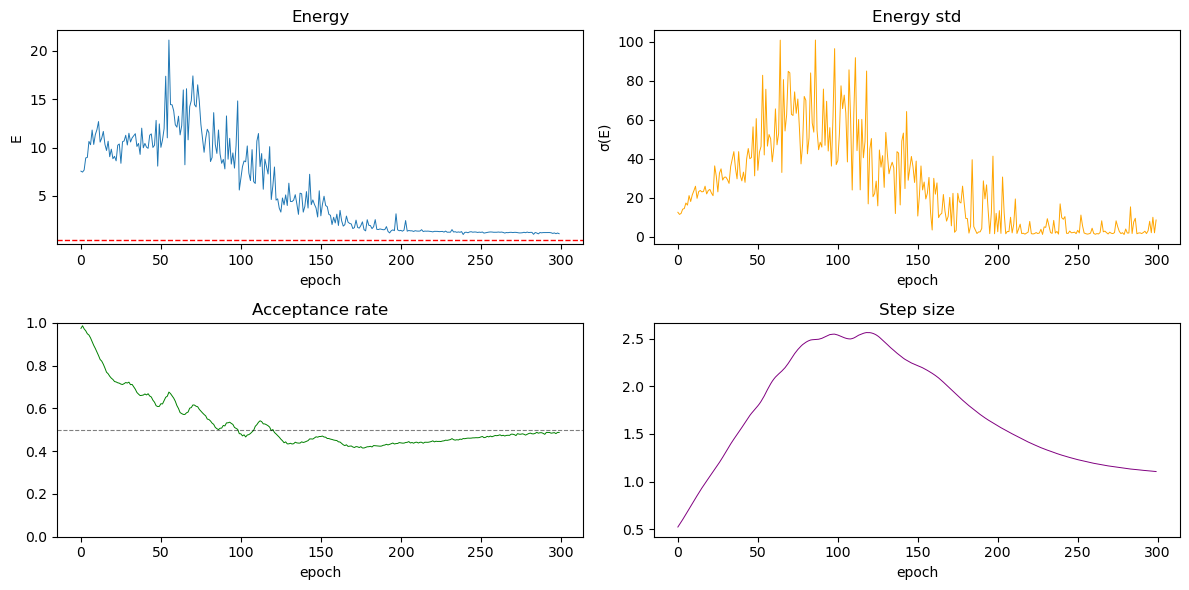

In [38]:
# ── Full diagnostic plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0,0].plot(energies_arr, lw=0.7); axes[0,0].axhline(0.5, color='r', ls='--', lw=1)
axes[0,0].set(title='Energy', xlabel='epoch', ylabel='E')

axes[0,1].plot(stds_arr, lw=0.7, color='orange')
axes[0,1].set(title='Energy std', xlabel='epoch', ylabel='σ(E)')

axes[1,0].plot(acc_arr, lw=0.7, color='green')
axes[1,0].axhline(0.5, color='k', ls='--', lw=0.8, alpha=0.5)
axes[1,0].set(title='Acceptance rate', xlabel='epoch', ylim=(0,1))

axes[1,1].plot(step_arr, lw=0.7, color='purple')
axes[1,1].set(title='Step size', xlabel='epoch')

plt.tight_layout(); plt.show()


---

## 8. MCMC diagnostics — autocorrelation & ESS <a name='8-diagnostics'></a>

Run a **diagnostic chain** (separate from training) to measure how correlated
consecutive samples are. The integrated autocorrelation time τ_int tells you the
minimum thinning factor needed for near-independent samples.

τ_int = 1 + 2 Σ_{t≥1} ρ_t,   ESS = n_steps / τ_int


In [58]:
# Use the trained HO model from §2
prob_fn_ho = build_prob_fn(model_ho.apply)
best_params = result_ho.best(1)[0].params

# Run a single chain for many steps
diag_steps, diag_dof, diag_step_size = 4000, 1, float(result_ho.history[-1].step_size)
rand_diag = jax.random.normal(jax.random.PRNGKey(99), (diag_steps, diag_dof + 1))
init_pos_diag = jnp.zeros(diag_dof)

positions_diag, ar = mh_chain(
    rand_diag, 0.0, prob_fn_ho, best_params, init_pos_diag, diag_step_size
)
print(f'Chain length: {diag_steps}, acceptance rate: {float(ar):.3f}')

tau  = integrated_autocorr_time(positions_diag[:, 0])
ess  = effective_sample_size(positions_diag[:, 0])
print(f'τ_int = {float(tau):.1f}')
print(f'ESS   = {float(ess):.1f} / {diag_steps}')
print(f'Recommended thinning_factor ≥ {int(float(tau)) + 1}')


Chain length: 4000, acceptance rate: 0.184
τ_int = 15.5
ESS   = 258.3 / 4000
Recommended thinning_factor ≥ 16


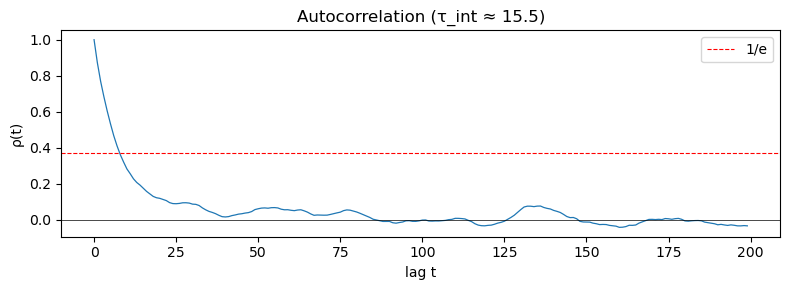

In [40]:
# Full ACF plot
rho = autocorr(positions_diag[:, 0], max_lag=200)

plt.figure(figsize=(8, 3))
plt.plot(rho, lw=0.9)
plt.axhline(0, color='k', lw=0.5)
plt.axhline(1 / np.e, color='r', ls='--', lw=0.8, label='1/e')
plt.xlabel('lag t'); plt.ylabel('ρ(t)')
plt.title(f'Autocorrelation (τ_int ≈ {float(tau):.1f})')
plt.legend(); plt.tight_layout(); plt.show()


Per-chain τ_int (mean ± std): 8.0 ± 10.8
Per-chain ESS   (mean ± std): 921.6 ± 1352.5


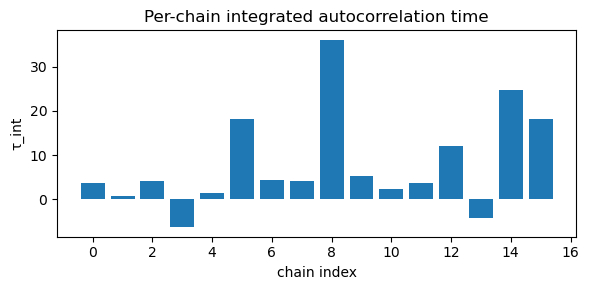

In [41]:
# Summarise all chains at once with chain_stats
n_chains_diag = 16
rand_all_diag = jax.random.normal(jax.random.PRNGKey(7), (n_chains_diag, diag_steps, diag_dof + 1))
init_all = jax.random.normal(jax.random.PRNGKey(8), (n_chains_diag, diag_dof)) * 0.3

vmapped_chain = jax.vmap(mh_chain, in_axes=(0, None, None, None, 0, None))
all_pos, all_ar = vmapped_chain(
    rand_all_diag, 0.0, prob_fn_ho, best_params, init_all, diag_step_size
)
# all_pos: (n_chains_diag, diag_steps, diag_dof)

taus_all, ess_all = chain_stats(all_pos)
print(f'Per-chain τ_int (mean ± std): {float(taus_all.mean()):.1f} ± {float(taus_all.std()):.1f}')
print(f'Per-chain ESS   (mean ± std): {float(ess_all.mean()):.1f} ± {float(ess_all.std()):.1f}')

plt.figure(figsize=(6, 3))
plt.bar(range(n_chains_diag), taus_all)
plt.xlabel('chain index'); plt.ylabel('τ_int')
plt.title('Per-chain integrated autocorrelation time')
plt.tight_layout(); plt.show()


---

## 9. Block sampling <a name='9-block'></a>

`block_size > 0` reduces peak **random-number** memory from
O(B·S·dof) to O(B·block_size·dof) by generating random numbers in chunks
inside a `fori_loop`.

The position buffer `(B, S, dof)` is still allocated in full (needed for
burn-in / thinning).  Use this when the random-number matrix is the bottleneck.


In [42]:
import time

model_bs = MLP(architecture=[1, 16, 1])
ham_bs   = HarmonicOscillatorHamiltonian()
tc_bs    = TrainingConfig(n_epochs=30)

for bs in [0, 50, 25]:
    t0 = time.time()
    r = train(
        shape=(400, 1),
        model=model_bs,
        optimizer=optax.adam(3e-3),
        hamiltonian=ham_bs,
        training_config=tc_bs,
        sampler_params=SamplingConfig(
            step_size=0.5, chain_length=100, thermalization_steps=10,
            thinning_factor=2, PBC=0.0, block_size=bs,
        ),
    )
    elapsed = time.time() - t0
    label = f'block_size={bs}' if bs > 0 else 'no blocking   '
    print(f'{label}: E={r.history[-1].energy:.4f}  time={elapsed:.2f}s')

print()
print('Note: energies differ because block_size changes the random-number stream.')
print('All paths sample correctly from |ψ|²; block_size only affects memory layout.')


100%|██████████| 30/30 [00:01<00:00, 29.07it/s, E=6.3422, sigma_E=10.7800]


no blocking   : E=5.8885  time=1.59s


100%|██████████| 30/30 [00:01<00:00, 27.61it/s, E=7.0397, sigma_E=12.7799]


block_size=50: E=6.4359  time=1.10s


100%|██████████| 30/30 [00:01<00:00, 28.39it/s, E=6.8324, sigma_E=12.1424]

block_size=25: E=5.7108  time=1.07s

Note: energies differ because block_size changes the random-number stream.
All paths sample correctly from |ψ|²; block_size only affects memory layout.


**When to use `block_size`:**

```
peak_rand_bytes = n_chains * chain_length * (dof + 1) * 4  # float32
```

Example: n_chains=2000, chain_length=1000, dof=50 → 400 MB.
With block_size=100: 40 MB peak for random numbers.


---

## 10. Laplacian methods <a name='10-laplacian'></a>

The kinetic energy requires computing ∆log|ψ| + |∇log|ψ||². Four methods:

| Method | Cost | Memory | Notes |
|---|---|---|---|
| `forward_ad` | O(dof · T_bwd) | O(P) | default; exact; sequential |
| `hutchinson` | O(n_terms · T_bwd) | O(B·n_terms·P) | stochastic; parallel probes |
| `central_difference` | O(dof · T_fwd) | O(B·dof) | exact; no AD |
| `full_hessian` | O(dof · T_bwd) | O(B·dof²) | exact; debug only |


In [43]:
import time

# Compare all four on the same system
N_lap = 5
ham_lap = HarmonicOscillatorHamiltonian()
tc_lap  = TrainingConfig(n_epochs=20)

methods = [
    ('forward_ad',        {}),
    ('central_difference',{}),
    ('hutchinson',        {'hutchinson_n_terms': 4}),
    ('full_hessian',      {}),
]

for method_name, extra_kwargs in methods:
    from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian as _H
    ham = _H(laplacian_method=method_name, **extra_kwargs)
    t0 = time.time()
    r = train(
        shape=(100, N_lap),
        model=MLP(architecture=[N_lap, 16, 1]),
        optimizer=optax.adam(3e-3),
        hamiltonian=ham,
        training_config=tc_lap,
        sampler_params={'step_size': 0.3, 'chain_length': 40,
                        'thermalization_steps': 4, 'thinning_factor': 1},
    )
    elapsed = time.time() - t0
    print(f'{method_name:20s}: E = {r.history[-1].energy:.4f}  ({elapsed:.2f}s)')


100%|██████████| 20/20 [00:01<00:00, 10.86it/s, E=5.6185, sigma_E=4.8346]


forward_ad          : E = 5.5827  (2.47s)


100%|██████████| 20/20 [00:01<00:00, 13.11it/s, E=-127.2326, sigma_E=8143.4395]


central_difference  : E = -250.1743  (1.54s)


100%|██████████| 20/20 [00:01<00:00, 12.88it/s, E=5.5663, sigma_E=4.8041]


hutchinson          : E = 5.6017  (1.57s)


100%|██████████| 20/20 [00:01<00:00, 13.84it/s, E=5.6185, sigma_E=4.8346]

full_hessian        : E = 5.5827  (1.46s)


In [44]:
# Hutchinson: tune n_terms vs variance tradeoff
# More terms → lower variance but higher cost; n_terms = dof → equivalent to forward_ad
key_h = jax.random.PRNGKey(42)
N_h = 6
model_h = MLP(architecture=[N_h, 32, 1])
params_h = model_h.init(key_h, jnp.ones((1, N_h)))
samples_h = jax.random.normal(key_h, (32, N_h))

from qvarnet.hamiltonian.laplacian import laplacian_forward_ad, laplacian_hutchinson
from qvarnet.hamiltonian.kinetic import kinetic_log
from functools import partial

def log_psi(x): return model_h.apply(params_h, x[None])[0, 0]

ref = kinetic_log(params_h, samples_h, model_h.apply, laplacian_forward_ad)
for n_t in [1, 2, 4, 8, N_h]:
    lap_fn = partial(laplacian_hutchinson, n_terms=n_t, distribution='rademacher')
    est = kinetic_log(params_h, samples_h, model_h.apply, lap_fn,
                      key=jax.random.PRNGKey(n_t))
    mae = float(jnp.mean(jnp.abs(est - ref)))
    print(f'n_terms={n_t:2d}  MAE vs forward_ad: {mae:.4f}')


n_terms= 1  MAE vs forward_ad: 0.2553
n_terms= 2  MAE vs forward_ad: 0.1303
n_terms= 4  MAE vs forward_ad: 0.1230
n_terms= 8  MAE vs forward_ad: 0.0994
n_terms= 6  MAE vs forward_ad: 0.1322


---

## 11. Stochastic reconfiguration (QGT) <a name='11-qgt'></a>

Stochastic reconfiguration (SR) preconditions the gradient by the
inverse quantum geometric tensor S⁻¹. It often converges faster than plain Adam
for small systems. Enable with `use_qgt=True`.

The `QGTConfig` controls the regularisation and linear solver.


In [45]:
from qvarnet.qgt import QGTConfig

qgt_cfg = QGTConfig(
    regularization=1e-3,
    solver='cholesky',      # 'cholesky' | 'gmres' | 'diagonal'
)

result_qgt = train(
    shape=(300, 1),
    model=MLP(architecture=[1, 16, 1]),
    optimizer=optax.sgd(1e-2),   # SR handles the curvature; SGD as base
    hamiltonian=HarmonicOscillatorHamiltonian(),
    training_config=TrainingConfig(n_epochs=80, use_qgt=True),
    sampler_params={'step_size': 0.4, 'chain_length': 80,
                    'thermalization_steps': 8, 'thinning_factor': 1},
    qgt_config=qgt_cfg,
)
print(f'QGT final E = {result_qgt.history[-1].energy:.4f}  (exact 0.5)')


100%|██████████| 80/80 [00:02<00:00, 35.02it/s, E=1.6793, sigma_E=2.6959]

QGT final E = 1.3599  (exact 0.5)


---

## 12. Callbacks <a name='12-callbacks'></a>

Callbacks run after every epoch **outside JIT**. Return `True` from
`on_step_end` to stop training early.

Available built-ins: `CheckpointCallback`, `NaNCallback`, `ProgressCallback`.


In [46]:
class LoggingCallback(Callback):
    """Print a message every log_every epochs."""
    def __init__(self, log_every=20):
        self.log_every = log_every

    def on_step_end(self, step, state, metrics):
        if step % self.log_every == 0:
            print(f'  step {step:4d}: E={metrics["energy"]:+.4f}  σ={metrics["std"]:.4f}'
                  f'  acc={float(metrics["acceptance_rate"].mean()):.2f}')
        return False

    def on_train_end(self, state, history):
        print(f'Training complete. {len(history)} epochs.')


class EarlyStopCallback(Callback):
    """Stop when std / |energy| < tol."""
    def __init__(self, tol=0.005, min_epoch=50):
        self.tol = tol
        self.min_epoch = min_epoch

    def on_step_end(self, step, state, metrics):
        if step < self.min_epoch:
            return False
        rel = abs(metrics['std']) / (abs(metrics['energy']) + 1e-8)
        if rel < self.tol:
            print(f'  Early stop at step {step}: rel_unc={rel:.4f} < {self.tol}')
            return True
        return False


result_cb = train(
    shape=(300, 1),
    model=MLP(architecture=[1, 32, 1]),
    optimizer=optax.adam(3e-3),
    hamiltonian=HarmonicOscillatorHamiltonian(),
    training_config=TrainingConfig(n_epochs=200),
    sampler_params={'step_size': 0.4, 'chain_length': 80,
                    'thermalization_steps': 8, 'thinning_factor': 2},
    callbacks=[LoggingCallback(log_every=50), EarlyStopCallback(tol=0.02)],
)
print(f'Epochs run: {len(result_cb.history)}')


 36%|███▌      | 72/200 [00:01<00:01, 88.09it/s, E=0.7844, sigma_E=1.3350]

  step    0: E=+4.4658  σ=7.2249  acc=0.93
  step   50: E=+2.3653  σ=4.5482  acc=0.93
  step  100: E=+1.0318  σ=2.0641  acc=0.82


100%|██████████| 200/200 [00:01<00:00, 154.75it/s, E=0.6563, sigma_E=0.9914]

  step  150: E=+0.8700  σ=2.6341  acc=0.77
Training complete. 200 epochs.
Epochs run: 200


---

## 13. Checkpointing <a name='13-checkpoints'></a>

Checkpoints are msgpack files written to `checkpoint_path`.
Re-running `train()` with the same path **resumes automatically** from the last saved step.


In [47]:
import tempfile, os

ckpt_dir = tempfile.mkdtemp(prefix='qvarnet_ckpt_')
print(f'Checkpoint dir: {ckpt_dir}')

# First run: 30 epochs, saves every 50 (so no intermediate saves here)
result_ckpt1 = train(
    shape=(200, 1),
    model=MLP(architecture=[1, 16, 1]),
    optimizer=optax.adam(3e-3),
    hamiltonian=HarmonicOscillatorHamiltonian(),
    training_config=TrainingConfig(
        n_epochs=60,
        save_checkpoints=True,
        checkpoint_path=ckpt_dir,
    ),
    sampler_params={'step_size': 0.4, 'chain_length': 40, 'thermalization_steps': 4, 'thinning_factor': 1},
)
print(f'Run 1 final step: {result_ckpt1.history[-1].step}')
print(f'Checkpoint files: {os.listdir(ckpt_dir)}')


Checkpoint dir: /tmp/qvarnet_ckpt_4hfnxf0l


100%|██████████| 60/60 [00:01<00:00, 59.30it/s, E=1.4723, sigma_E=2.4812]

Run 1 final step: 59
Checkpoint files: ['checkpoints']


In [48]:
# Resume: train() with same checkpoint_path picks up from the saved step
result_ckpt2 = train(
    shape=(200, 1),
    model=MLP(architecture=[1, 16, 1]),
    optimizer=optax.adam(3e-3),
    hamiltonian=HarmonicOscillatorHamiltonian(),
    training_config=TrainingConfig(
        n_epochs=120,                  # total epochs (resumes from step ~50)
        save_checkpoints=True,
        checkpoint_path=ckpt_dir,
    ),
    sampler_params={'step_size': 0.4, 'chain_length': 40, 'thermalization_steps': 4, 'thinning_factor': 1},
)
print(f'Run 2 started at step: {result_ckpt2.history[0].step}')
print(f'Run 2 final   energy: {result_ckpt2.history[-1].energy:.4f}')


100%|██████████| 69/69 [00:01<00:00, 56.64it/s, E=0.8081, sigma_E=1.3889]

Run 2 started at step: 51
Run 2 final   energy: 0.8383


---

## 14. Custom Hamiltonian <a name='14-custom-hamiltonian'></a>

Steps:
1. Subclass `ContinuousHamiltonian`
2. Implement `potential_energy(self, samples) -> (batch,)` — receives **lab** coordinates
3. Decorate with `@register_hamiltonian('my-name')` (optional, for YAML runner)

All fields must be Flax `struct.field`; non-JAX-array fields need `pytree_node=False`.


In [49]:
from flax import struct
from qvarnet.hamiltonian.continuous import ContinuousHamiltonian
from qvarnet.hamiltonian.hamiltonian_registry import register_hamiltonian


@register_hamiltonian('double-well')
@struct.dataclass
class DoubleWellHamiltonian(ContinuousHamiltonian):
    """V(x) = (x² − a²)² — two wells at x = ±a."""

    a: float = 1.0     # well locations
    lam: float = 1.0   # overall scale

    def potential_energy(self, samples):
        # samples: (batch, dof)
        r2 = jnp.sum(samples ** 2, axis=-1)   # (batch,)
        return self.lam * (r2 - self.a ** 2) ** 2


dw = DoubleWellHamiltonian(a=1.5, lam=0.5)
print('Potential at x=0:', dw.potential_energy(jnp.zeros((4, 1))))
print('Potential at x=a:', dw.potential_energy(jnp.ones((4, 1)) * 1.5))

result_dw = train(
    shape=(300, 1),
    model=MLP(architecture=[1, 32, 32, 1]),
    optimizer=optax.adam(2e-3),
    hamiltonian=dw,
    training_config=TrainingConfig(n_epochs=200, is_update_step_size=True),
    sampler_params={'step_size': 0.3, 'chain_length': 100, 'thermalization_steps': 10, 'thinning_factor': 2},
)
print(f'Double-well E = {result_dw.history[-1].energy:.4f}')


Potential at x=0: [2.53125 2.53125 2.53125 2.53125]
Potential at x=a: [0. 0. 0. 0.]


100%|██████████| 200/200 [00:03<00:00, 56.83it/s, E=177106.1250, sigma_E=2730117.2500] 

Double-well E = 24256.9434


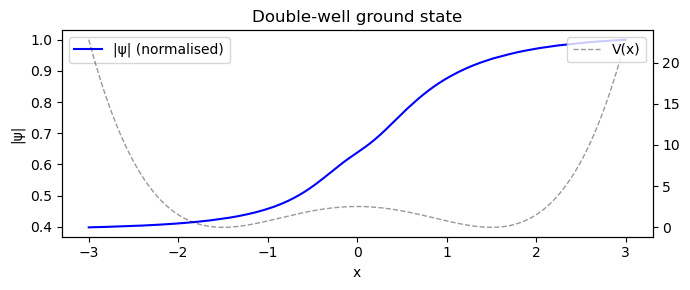

In [50]:
# Plot the wavefunction on the learned ground state
best_dw = result_dw.best(1)[0]
x_grid  = jnp.linspace(-3, 3, 200)[:, None]
log_psi_vals = model_ho.apply(result_ho.best(1)[0].params, x_grid).squeeze()  # just for shape check

# Use the double-well model
best_model_dw_params = best_dw.params
log_psi_dw = MLP(architecture=[1, 32, 32, 1]).apply(best_model_dw_params, x_grid).squeeze()
psi_dw = jnp.exp(log_psi_dw)
V_dw   = dw.lam * (x_grid.squeeze() ** 2 - dw.a ** 2) ** 2

fig, ax = plt.subplots(figsize=(7, 3))
ax2 = ax.twinx()
ax2.plot(x_grid, V_dw, 'k--', lw=1, alpha=0.4, label='V(x)')
ax.plot(x_grid, psi_dw / float(jnp.max(psi_dw)), 'b', lw=1.5, label='|ψ| (normalised)')
ax.set(xlabel='x', ylabel='|ψ|', title='Double-well ground state')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()


---

## 15. Custom model <a name='15-custom-model'></a>

Any `flax.linen.Module` that maps `(batch, dof) → (batch, 1)` works.
Decorate with `@register_model('name')` to make it available in the YAML runner.


In [51]:
from flax import linen as nn
from qvarnet.models.registry import register_model


@register_model('jastrow-mlp')
class JastrowMLP(nn.Module):
    """Two-body Jastrow factor: log|ψ| = Σᵢ u(xᵢ) + Σᵢ<ⱼ v(xᵢ − xⱼ).

    This naive implementation computes both one-body and pair terms via MLPs.
    """
    n_particles: int
    n_dim: int
    hidden: int = 16

    @nn.compact
    def __call__(self, x):
        shape = x.shape[:-1]
        r = x.reshape(*shape, self.n_particles, self.n_dim)  # (..., N, d)

        # One-body term: u(xᵢ) for each particle
        u = nn.Dense(self.hidden)(r); u = nn.tanh(u)
        u = nn.Dense(1)(u)  # (..., N, 1)
        one_body = jnp.sum(u, axis=-2)  # (..., 1)

        # Two-body term: v(xᵢ − xⱼ) for each pair
        i_idx, j_idx = jnp.triu_indices(self.n_particles, k=1)
        diffs = r[..., i_idx, :] - r[..., j_idx, :]  # (..., n_pairs, d)
        v = nn.Dense(self.hidden)(diffs); v = nn.tanh(v)
        v = nn.Dense(1)(v)  # (..., n_pairs, 1)
        two_body = jnp.sum(v, axis=-2)  # (..., 1)

        return one_body + two_body


N_j, d_j = 3, 1
jastrow = JastrowMLP(n_particles=N_j, n_dim=d_j, hidden=16)
x_j = jnp.ones((4, N_j * d_j))
params_j = jastrow.init(key, x_j)
print('Jastrow output shape:', jastrow.apply(params_j, x_j).shape)

result_jastrow = train(
    shape=(200, N_j * d_j),
    model=jastrow,
    optimizer=optax.adam(3e-3),
    hamiltonian=HarmonicOscillatorHamiltonian(),
    training_config=TrainingConfig(n_epochs=100),
    sampler_params={'step_size': 0.4, 'chain_length': 60, 'thermalization_steps': 6, 'thinning_factor': 1},
)
print(f'Jastrow MLP E = {result_jastrow.history[-1].energy:.4f}  (exact = 1.5 for 3 HO)')


Jastrow output shape: (4, 1)


100%|██████████| 100/100 [00:01<00:00, 59.38it/s, E=2.7856, sigma_E=3.0947]

Jastrow MLP E = 2.3597  (exact = 1.5 for 3 HO)


---

## 16. Auxiliary losses — cusp condition <a name='16-cusp'></a>

The cusp condition enforces the correct short-range behaviour of ψ near
particle coincidences. Enable via `CuspConfig` in `TrainingConfig`.

For the Calogero-Sutherland model with coupling L:
ψ(xᵢ, xⱼ) ~ |xᵢ − xⱼ|^L  as xᵢ → xⱼ.


In [52]:
from qvarnet.config.training_setup import CuspConfig

cs_with_cusp = CalogeroSutherlandHamiltonian(
    L=2.0, epsilon=1e-3, omega_trap=1.0,
)

cusp_cfg = CuspConfig(
    alpha=0.1,               # cusp loss weight relative to VMC loss
    epsilon=5e-3,            # distance at which cusp condition is enforced
    n_configs_per_pair=8,
    n=2.0,                   # power-law exponent (2 for CS model)
    C_n=2.0,                 # target cusp amplitude = L
)

N_cs = 3
result_cusp = train(
    shape=(300, N_cs),
    model=MLP(architecture=[N_cs, 64, 64, 1]),
    optimizer=optax.adam(1e-3),
    hamiltonian=cs_with_cusp,
    training_config=TrainingConfig(
        n_epochs=100,
        is_update_step_size=True,
        cusp=cusp_cfg,
    ),
    sampler_params={'step_size': 0.2, 'chain_length': 80, 'thermalization_steps': 8, 'thinning_factor': 2},
)
print(f'CS + cusp condition final E = {result_cusp.history[-1].energy:.4f}')


100%|██████████| 100/100 [00:06<00:00, 14.50it/s, E=175.4481, sigma_E=216.7408]

CS + cusp condition final E = 180.6687


---

## 17. YAML config runner <a name='17-yaml'></a>

Run experiments from a YAML file — useful for reproducibility and cluster sweeps.

```bash
# CLI
uv run python -m qvarnet.runner experiments/harmonic_oscillator.yaml
uv run python -m qvarnet.runner my_exp.yaml --set training.n_epochs=5000 optimizer.learning_rate=1e-4
```


In [53]:
import tempfile, os, yaml as _yaml
from qvarnet.runner import run

# ── Write a config file ─────────────────────────────────────────────────────
config_content = '''
output_dir: /tmp/yaml_runner_demo

shape:
  n_chains: 200
  n_particles: 1
  n_dim: 1

model:
  type: mlp
  architecture: [1, 32, 32, 1]

hamiltonian:
  type: harmonic-oscillator
  omega: 1.0

optimizer:
  type: adam
  learning_rate: 3.0e-3

training:
  n_epochs: 60
  is_update_step_size: true

sampler:
  step_size: 0.4
  chain_length: 60
  thermalization_steps: 6
  thinning_factor: 2
  block_size: 0

coord_mode:
  type: lab
'''

cfg_path = '/tmp/demo_experiment.yaml'
with open(cfg_path, 'w') as f:
    f.write(config_content)
print(f'Config written to {cfg_path}')


Config written to /tmp/demo_experiment.yaml


In [54]:
# Run via Python API (equivalent to the CLI)
result_yaml = run(
    cfg_path,
    overrides=['training.n_epochs=80'],    # list of 'section.key=value' strings
)
print(f'YAML runner final E = {result_yaml.history[-1].energy:.4f}')
print(f'Output files: {os.listdir("/tmp/yaml_runner_demo")}')


  Experiment : demo_experiment
  Output     : /tmp/yaml_runner_demo
  Shape      : n_chains=200, dof=1
  Model      : mlp
  Hamiltonian: harmonic-oscillator
  Epochs     : 80


100%|██████████| 80/80 [00:03<00:00, 25.58it/s, E=6.2123, sigma_E=18.2907]

Saved  energy_history.csv → /tmp/yaml_runner_demo/energy_history.csv
Best energy : 2.892351  ±  4.738277
YAML runner final E = 6.2156
Output files: ['energy_history.csv', 'config.yaml', 'checkpoints']


In [55]:
# CLI override syntax (shown here as a Python subprocess for demonstration)
import subprocess, sys

proc = subprocess.run(
    [sys.executable, '-m', 'qvarnet.runner', cfg_path,
     '--set', 'training.n_epochs=30', 'optimizer.learning_rate=1e-3'],
    capture_output=True, text=True,
    cwd='/home/pau/PhD/qvarnet',
)
# Just show a few lines of output
output_lines = (proc.stdout + proc.stderr).strip().split('\n')
for line in output_lines[:10]:
    print(line)


  Experiment : demo_experiment
  Output     : /tmp/yaml_runner_demo
  Shape      : n_chains=200, dof=1
  Model      : mlp
  Hamiltonian: harmonic-oscillator
  Epochs     : 30
E0520 00:46:08.342906   90571 cuda_blas.cc:196] failed to create cublas handle: the resource allocation failed
E0520 00:46:08.342932   90571 cuda_blas.cc:199] Failure to initialize cublas may be due to OOM (cublas needs some free memory when you initialize it, and your deep-learning framework may have preallocated more than its fair share), or may be because this binary was not built with support for the GPU in your machine.


---

## Summary

| Feature | Import path | Key argument |
|---|---|---|
| MLP | `qvarnet.models.MLP` | `architecture=[in,...,1]` |
| DeepSet | `qvarnet.models.ExponentialDeepSet` | `n_particles, n_dim` |
| HO | `qvarnet.hamiltonian.continuous.HarmonicOscillatorHamiltonian` | `omega` |
| CS model | `...CalogeroSutherlandHamiltonian` | `L, pairwise_impl` |
| Training | `qvarnet.train` | `TrainingConfig, SamplingConfig` |
| Jacobi coords | `qvarnet.config.coord_mode.JacobiCoords` | `n_particles, n_dim` |
| Diagnostics | `qvarnet.samplers` | `integrated_autocorr_time, chain_stats` |
| Block sampling | `SamplingConfig(block_size=K)` | must divide `chain_length` |
| Hutchinson | `ContinuousHamiltonian(laplacian_method='hutchinson')` | `hutchinson_n_terms` |
| QGT | `TrainingConfig(use_qgt=True)` | `QGTConfig` |
| YAML runner | `qvarnet.runner.run(path, overrides)` | dot-notation overrides |
| Cusp loss | `TrainingConfig(cusp=CuspConfig(...))` | `alpha, epsilon, n, C_n` |
